In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import plotnine as pn
from plotnine import *
from tqdm import tqdm
import yaml
from collections import defaultdict

In [14]:
# Set up directories for T and NoT runs separately
OUTPUT_DIR_T = "/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/seed_genes_minmax_T"
OUTPUT_DIRS_NoT = [f"/gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/seed_genes_minmax_noT_b{i}" for i in range(1, 6)]

# Collect T runs
RUNS_T = []
if os.path.exists(OUTPUT_DIR_T):
    for run in os.listdir(OUTPUT_DIR_T):
        if "run" in run:
            RUNS_T.append(run)
RUNS_T = sorted(RUNS_T)

# Collect NoT runs - track which directory each run comes from
RUNS_NoT = []
run_to_dir = {}  # Map run_id to its directory
for batch_dir in OUTPUT_DIRS_NoT:
    if os.path.exists(batch_dir):
        batch_name = os.path.basename(batch_dir)  # e.g., "seed_genes_minmax_noT_b1"
        for run in os.listdir(batch_dir):
            if "run" in run and os.path.isdir(os.path.join(batch_dir, run)):
                # Create unique identifier: include directory info
                unique_run_id = f"{batch_name}/{run}"
                RUNS_NoT.append(unique_run_id)
                run_to_dir[unique_run_id] = batch_dir
RUNS_NoT = sorted(RUNS_NoT)

print(f"Found {len(RUNS_T)} T runs and {len(RUNS_NoT)} NoT runs")
print(f"T runs: {len(RUNS_T)}")
print(f"NoT runs: {len(RUNS_NoT)}")

Found 100 T runs and 472 NoT runs
T runs: 100
NoT runs: 472


In [15]:
# Organize runs by type (T vs NoT) and learning rate
lr_to_runs_T = defaultdict(list)
lr_to_runs_NoT = defaultdict(list)
epochs_to_runs = defaultdict(list)
run_to_clipnorm = {}
run_to_type = {}  # Track whether run is T or NoT

# Process T runs
for run_id in RUNS_T:
    config_file = os.path.join(OUTPUT_DIR_T, run_id, "config.yaml")
    if os.path.exists(config_file):
        try:
            with open(config_file, 'r') as f:
                config = yaml.safe_load(f)
            lr = config['lr']
            epochs = config['epochs']
            lr_to_runs_T[lr].append(run_id)
            epochs_to_runs[epochs].append(run_id)
            run_to_clipnorm[run_id] = config.get('clip_norm', True)
            run_to_type[run_id] = 'T'
        except Exception as e:
            print(f"Warning: Could not load config for T run {run_id}: {e}")

# Process NoT runs - use the unique run IDs from Cell 1
for unique_run_id in RUNS_NoT:
    # Extract base run name and directory
    if '/' in unique_run_id:
        batch_name, base_run_id = unique_run_id.split('/', 1)
        out_dir = run_to_dir[unique_run_id]
    else:
        # Fallback for old format
        base_run_id = unique_run_id
        out_dir = None
        for d in OUTPUT_DIRS_NoT:
            if os.path.exists(os.path.join(d, base_run_id)):
                out_dir = d
                break
    
    if out_dir:
        config_file = os.path.join(out_dir, base_run_id, "config.yaml")
        if os.path.exists(config_file):
            try:
                with open(config_file, 'r') as f:
                    config = yaml.safe_load(f)
                lr = config['lr']
                epochs = config['epochs']
                lr_to_runs_NoT[lr].append(unique_run_id)
                epochs_to_runs[epochs].append(unique_run_id)
                run_to_clipnorm[unique_run_id] = config.get('clip_norm', True)
                run_to_type[unique_run_id] = 'NoT'
            except Exception as e:
                print(f"Warning: Could not load config for NoT run {unique_run_id}: {e}")



In [16]:
def load_run_files(run_id, what=["losses", "tau_T", "tau_history", "times", "posterior", "beta", "mu", "r2"]): 
    result = {}
    
    # Handle new format: "seed_genes_minmax_noT_b1/run_1" or old format: "run_1"
    if '/' in run_id:
        # New format: extract directory and base run name
        batch_name, base_run_id = run_id.split('/', 1)
        # Use run_to_dir if available (from Cell 1)
        # Check both globals() and locals() to find run_to_dir
        run_to_dir_dict = None
        if 'run_to_dir' in globals():
            run_to_dir_dict = globals()['run_to_dir']
        elif 'run_to_dir' in locals():
            run_to_dir_dict = locals()['run_to_dir']
        
        if run_to_dir_dict is not None and run_id in run_to_dir_dict:
            run_dir = os.path.join(run_to_dir_dict[run_id], base_run_id)
            if not os.path.isdir(run_dir):
                run_dir = None
        else:
            run_dir = None
        
        # Fallback: find directory by batch name if run_to_dir didn't work
        if run_dir is None:
            for search_dir in OUTPUT_DIRS_NoT:
                # Match by exact batch name (use basename to avoid partial matches)
                search_basename = os.path.basename(search_dir)
                if batch_name == search_basename:
                    test_path = os.path.join(search_dir, base_run_id)
                    if os.path.isdir(test_path):
                        run_dir = test_path
                        break
    else:
        # Old format or T run: extract base run_id (remove suffix like _1, _2, etc. if present)
        parts = run_id.split('_')
        if len(parts) >= 3 and parts[-1].isdigit():
            base_run_id = '_'.join(parts[:-1])
        else:
            base_run_id = run_id
        
        # Search in both T and NoT directories
        search_dirs = [OUTPUT_DIR_T] + OUTPUT_DIRS_NoT
        
        # Find which directory contains this run
        run_dir = None
        for search_dir in search_dirs:
            if not os.path.exists(search_dir):
                continue
            for test_id in [run_id, base_run_id]:
                test_path = os.path.join(search_dir, test_id)
                if os.path.isdir(test_path):
                    run_dir = test_path
                    break
            if run_dir:
                break
    
    if run_dir is None:
        return result  # Return empty dict if run directory not found
    
    # Helper function to safely load file
    def safe_load_file(file_path, loader_func, **kwargs):
        if os.path.exists(file_path):
            try:
                return loader_func(file_path, **kwargs)
            except Exception:
                return None
        return None
    
    if "losses" in what:    
        losses_file = os.path.join(run_dir, "losses.txt")
        result["losses"] = safe_load_file(losses_file, pd.read_csv, header=None)
    if "tau_T" in what:
        tau_T_file = os.path.join(run_dir, "tau_T.csv")
        result["tau_T"] = safe_load_file(tau_T_file, pd.read_csv)
    if "tau_history" in what:
        tau_history_file = os.path.join(run_dir, "tau_history.csv")
        result["tau_history"] = safe_load_file(tau_history_file, pd.read_csv, index_col=0)
    if "times" in what:
        times_file = os.path.join(run_dir, "times.txt")
        result["times"] = safe_load_file(times_file, pd.read_csv)
    if "posterior" in what:
        posterior_file = os.path.join(run_dir, "posterior_stats.npz")
        result["posterior"] = safe_load_file(posterior_file, np.load, allow_pickle=True)
    if "beta" in what:
        beta_file = os.path.join(run_dir, "beta_samples", "all_beta_samples.npz")
        result["beta"] = safe_load_file(beta_file, np.load, allow_pickle=True)
    if "mu" in what:
        mu_file = os.path.join(run_dir, "mu_samples", "all_mu_samples.npz")
        result["mu"] = safe_load_file(mu_file, np.load, allow_pickle=True)
    if "r2_test" in what:
        r2_file = os.path.join(run_dir, "test_r2_scores.csv")
        result["r2_test"] = safe_load_file(r2_file, pd.read_csv)
    if "r2_train" in what:
        r2_file = os.path.join(run_dir, "train_r2_scores.csv")
        result["r2_train"] = safe_load_file(r2_file, pd.read_csv)
    
    return result

In [17]:
# Helper function to find config file across directories
def find_config_file(run_id):
    """Find config.yaml file for a run across all output directories."""
    # Handle new format: "seed_genes_minmax_noT_b1/run_1" or old format: "run_1"
    if '/' in run_id:
        # New format: extract directory and base run name
        batch_name, base_run_id = run_id.split('/', 1)
        # Use run_to_dir if available (from Cell 1)
        if 'run_to_dir' in globals() and run_id in run_to_dir:
            config_path = os.path.join(run_to_dir[run_id], base_run_id, "config.yaml")
            if os.path.exists(config_path):
                return config_path
        else:
            # Fallback: find directory by exact batch name match
            for search_dir in OUTPUT_DIRS_NoT:
                search_basename = os.path.basename(search_dir)
                if batch_name == search_basename:
                    config_path = os.path.join(search_dir, base_run_id, "config.yaml")
                    if os.path.exists(config_path):
                        return config_path
    else:
        # Old format or T run: extract base run_id (remove suffix like _1, _2, etc. if present)
        parts = run_id.split('_')
        if len(parts) >= 3 and parts[-1].isdigit():
            base_run_id = '_'.join(parts[:-1])
        else:
            base_run_id = run_id
        
        search_dirs = [OUTPUT_DIR_T] + OUTPUT_DIRS_NoT
        for search_dir in search_dirs:
            if not os.path.exists(search_dir):
                continue
            for test_id in [run_id, base_run_id]:
                config_path = os.path.join(search_dir, test_id, "config.yaml")
                if os.path.exists(config_path):
                    return config_path
    return None


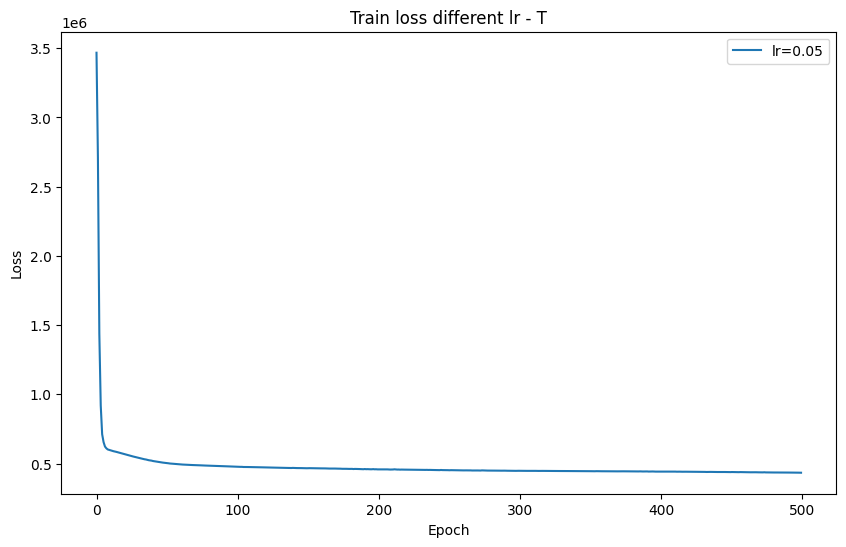

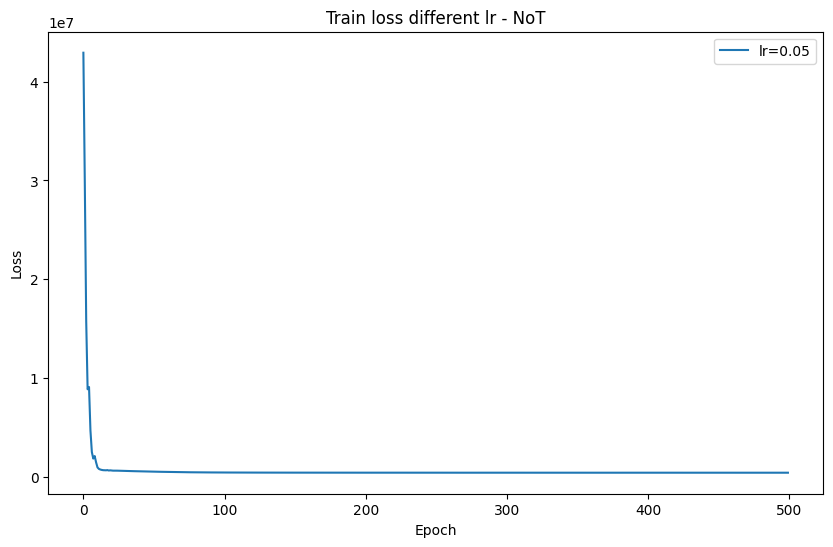

In [ ]:
# Plot losses for T and NoT separately
for run_type, lr_dict in [('T', lr_to_runs_T), ('NoT', lr_to_runs_NoT)]:
    if len(lr_dict) == 0:
        continue
    plt.figure(figsize=(10, 6))
    for lr, runs in lr_dict.items():
        if len(runs) > 0:
            run_id = runs[0]  # take first as representative
            losses = load_run_files(run_id, what=["losses"]).get("losses")
            if losses is not None:
                plt.plot(losses, label=f"lr={lr}")
    plt.title(f"Train loss different lr - {run_type}")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

Debug: seed_genes_minmax_noT_b1/run_1 -> /gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/seed_genes_minmax_noT_b1/run_1
Debug: seed_genes_minmax_noT_b1/run_10 -> /gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/seed_genes_minmax_noT_b1/run_10
Debug: seed_genes_minmax_noT_b1/run_11 -> /gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/seed_genes_minmax_noT_b1/run_11
Debug: seed_genes_minmax_noT_b1/run_12 -> /gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/seed_genes_minmax_noT_b1/run_12
Debug: seed_genes_minmax_noT_b1/run_13 -> /gpfs/commons/home/vmazeeva/firvTWAS/parmigiano-expr/src/seed_genes_minmax_noT_b1/run_13

Processing T runs (100 unique runs, batching by 10)


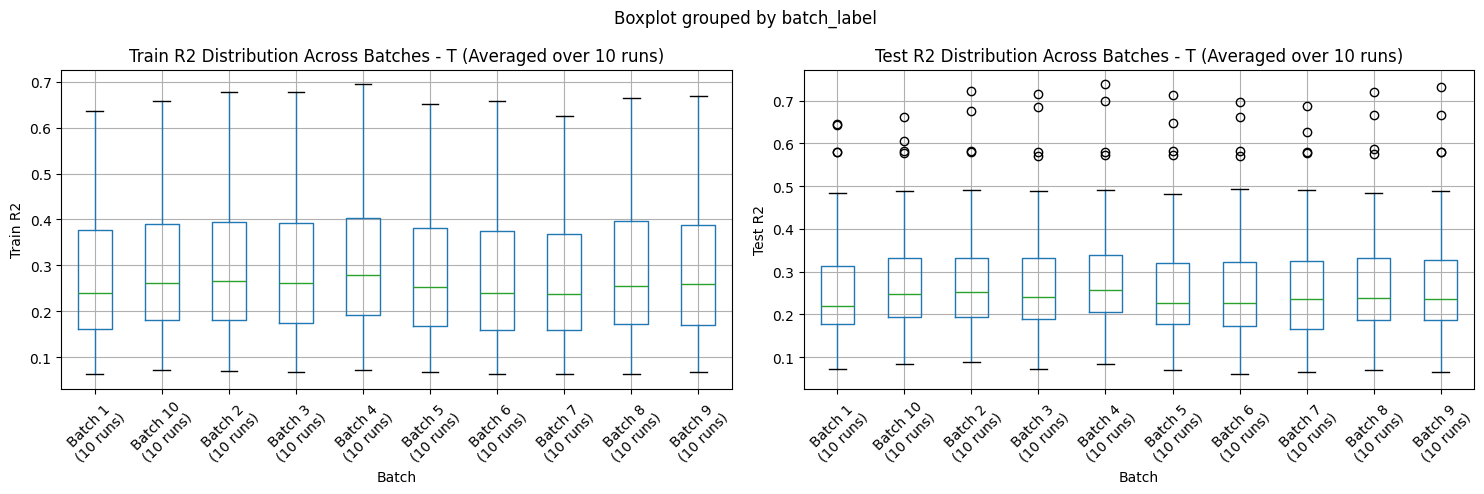

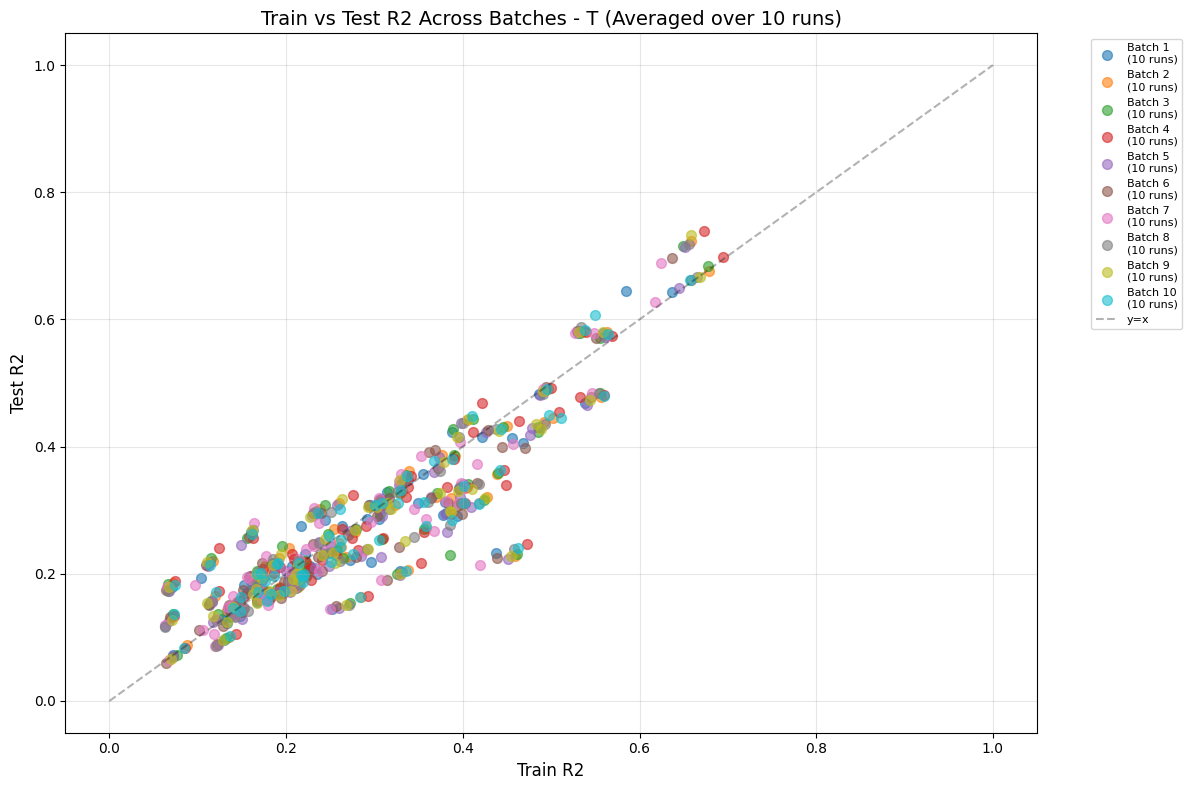

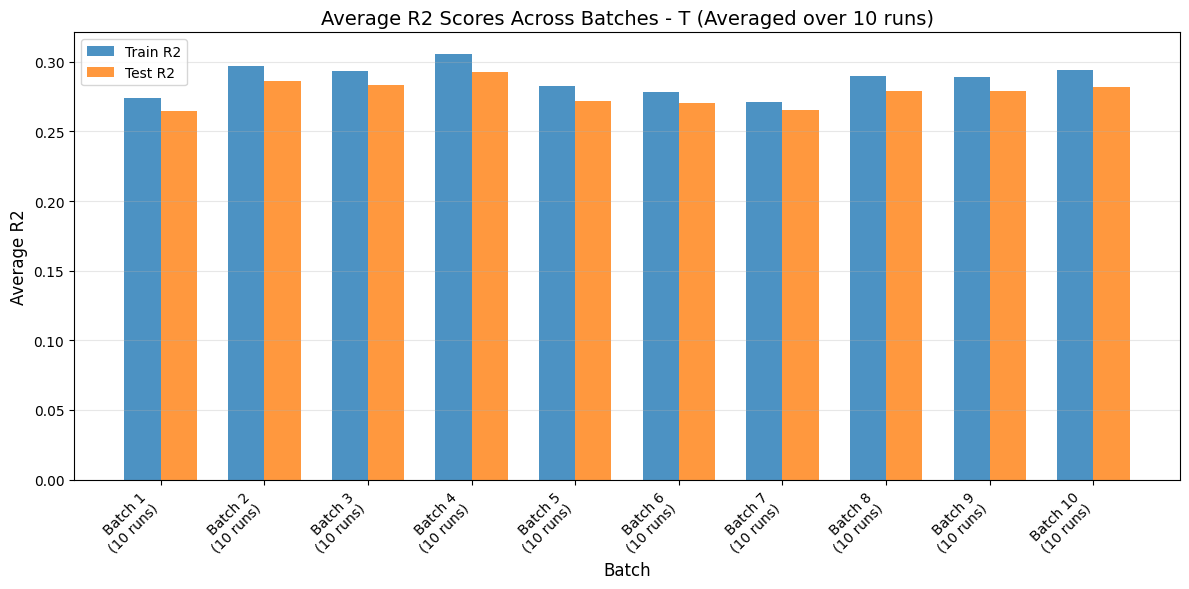


R2 Summary Statistics Across Batches - T (Averaged over 10 runs)
                    r2_train                         r2_test                  \
                        mean     std     min     max    mean     std     min   
Batch 1\n(10 runs)    0.2743  0.1398  0.0634  0.6367  0.2646  0.1319  0.0716   
Batch 2\n(10 runs)    0.2969  0.1454  0.0692  0.6785  0.2863  0.1352  0.0881   
Batch 3\n(10 runs)    0.2932  0.1461  0.0666  0.6780  0.2831  0.1365  0.0730   
Batch 4\n(10 runs)    0.3058  0.1477  0.0731  0.6950  0.2927  0.1375  0.0838   
Batch 5\n(10 runs)    0.2828  0.1442  0.0675  0.6512  0.2718  0.1359  0.0703   
Batch 6\n(10 runs)    0.2784  0.1453  0.0635  0.6584  0.2706  0.1366  0.0602   
Batch 7\n(10 runs)    0.2709  0.1417  0.0632  0.6246  0.2651  0.1353  0.0648   
Batch 8\n(10 runs)    0.2895  0.1464  0.0630  0.6647  0.2788  0.1375  0.0699   
Batch 9\n(10 runs)    0.2888  0.1459  0.0669  0.6684  0.2793  0.1376  0.0663   
Batch 10\n(10 runs)   0.2938  0.1409  0.0728  0.6573  

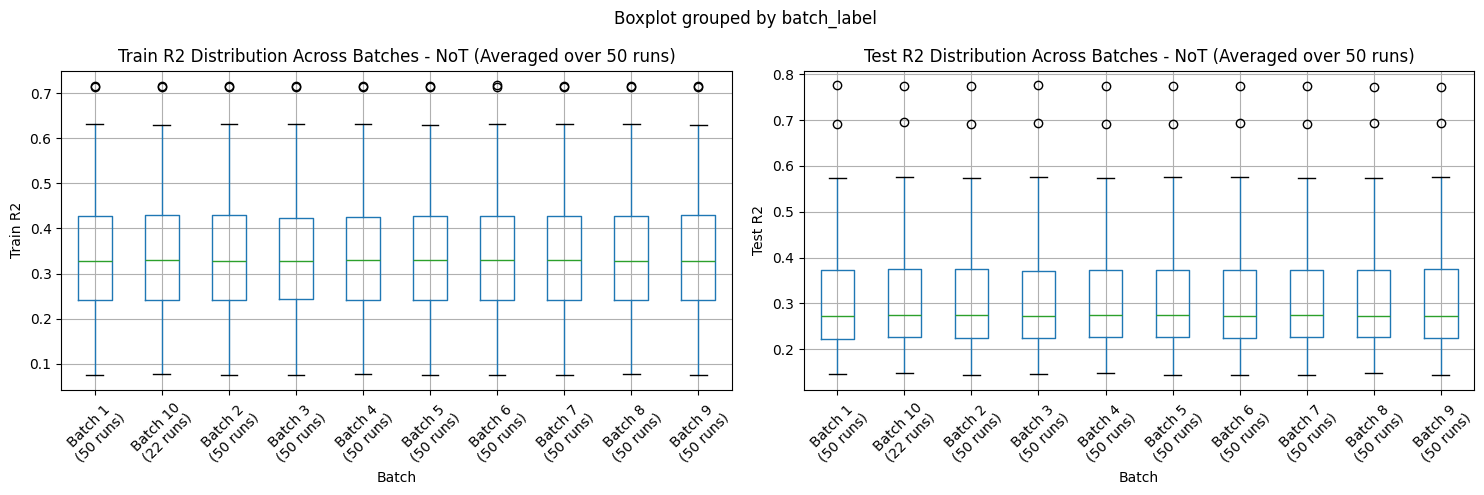

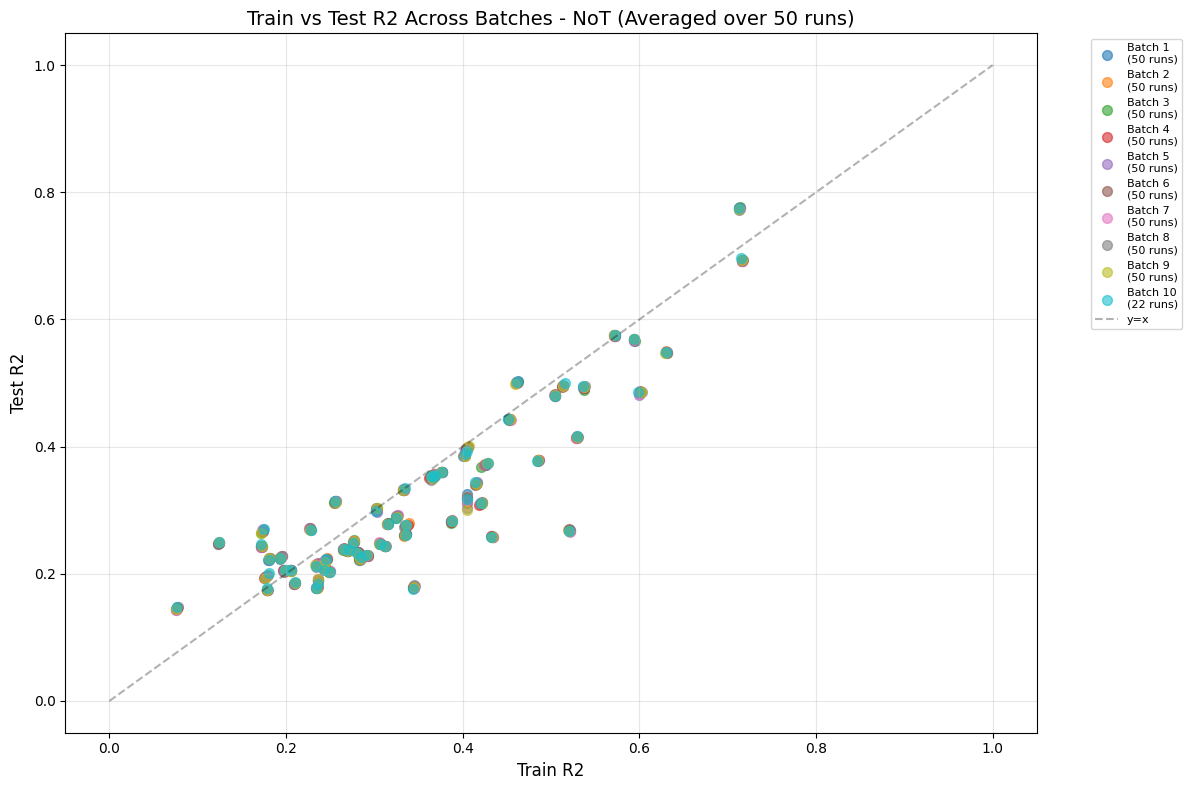

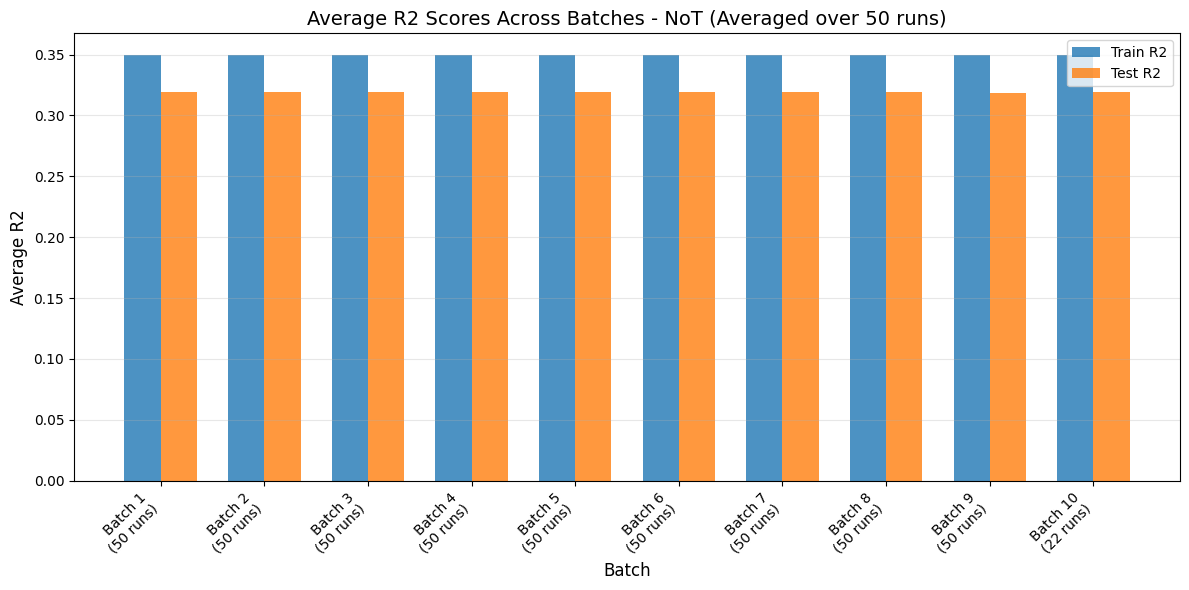


R2 Summary Statistics Across Batches - NoT (Averaged over 50 runs)
                    r2_train                         r2_test                  \
                        mean     std     min     max    mean     std     min   
Batch 1\n(50 runs)    0.3498  0.1449  0.0758  0.7166  0.3191  0.1328  0.1452   
Batch 2\n(50 runs)    0.3498  0.1450  0.0762  0.7162  0.3193  0.1327  0.1446   
Batch 3\n(50 runs)    0.3498  0.1449  0.0761  0.7162  0.3190  0.1327  0.1457   
Batch 4\n(50 runs)    0.3498  0.1448  0.0772  0.7164  0.3190  0.1325  0.1471   
Batch 5\n(50 runs)    0.3499  0.1449  0.0749  0.7158  0.3189  0.1325  0.1432   
Batch 6\n(50 runs)    0.3499  0.1450  0.0756  0.7175  0.3192  0.1328  0.1446   
Batch 7\n(50 runs)    0.3498  0.1450  0.0749  0.7161  0.3191  0.1325  0.1433   
Batch 8\n(50 runs)    0.3497  0.1450  0.0768  0.7160  0.3190  0.1325  0.1473   
Batch 9\n(50 runs)    0.3498  0.1450  0.0750  0.7162  0.3187  0.1327  0.1439   
Batch 10\n(22 runs)   0.3499  0.1447  0.0766  0.7153

/scratch/ipykernel_4173223/997425668.py:196: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/scratch/ipykernel_4173223/997425668.py:199: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
/scratch/ipykernel_4173223/997425668.py:196: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Eith

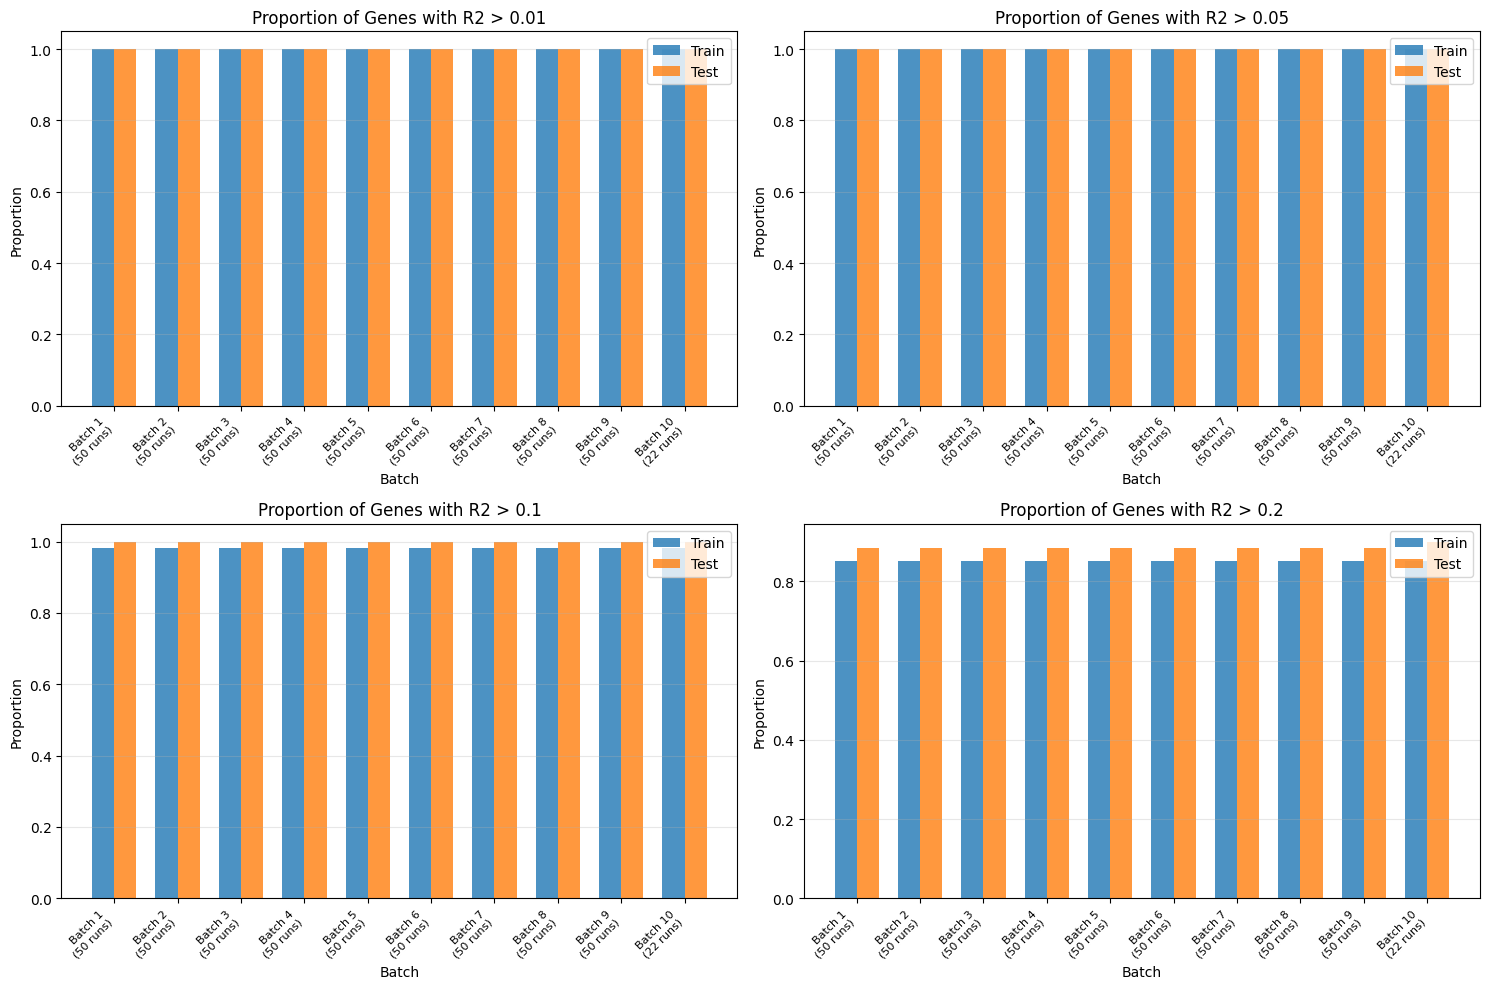

In [19]:
# Load R2 data from all runs, processing T and NoT separately
def process_r2_data(run_list, run_type):
    """Process R2 data for a list of runs."""
    r2_data = []
    loaded_dirs = {}  # Track which directory each run_id loads from
    for run_id in run_list:
        try:
            # Debug: Check which directory this run_id loads from
            if run_type == 'NoT' and len(loaded_dirs) < 10:  # Only check first 10 for debugging
                # Try to find the directory
                if '/' in run_id:
                    batch_name, base_run_id = run_id.split('/', 1)
                    if 'run_to_dir' in globals() and run_id in globals()['run_to_dir']:
                        loaded_dir = os.path.join(globals()['run_to_dir'][run_id], base_run_id)
                        loaded_dirs[run_id] = loaded_dir
                        if len(loaded_dirs) <= 5:  # Print first 5
                            print(f"Debug: {run_id} -> {loaded_dir}")
            
            r2_test = load_run_files(run_id, what=["r2_test"]).get("r2_test")
            r2_train = load_run_files(run_id, what=["r2_train"]).get("r2_train")
            if r2_test is not None and r2_train is not None:
                # Load config to get metadata
                config_file = find_config_file(run_id)
                if config_file:
                    with open(config_file, 'r') as f:
                        config = yaml.safe_load(f)
                    
                    # Merge train and test R2
                    r2_merged = r2_train.merge(r2_test, on='gene', suffixes=('_train', '_test'))
                    r2_merged['run_id'] = run_id
                    r2_merged['run_type'] = run_type
                    r2_merged['lr'] = config.get('lr', 'unknown')
                    r2_merged['epochs'] = config.get('epochs', 'unknown')
                    r2_data.append(r2_merged)
        except Exception as e:
            print(f"Warning: Could not load R2 data for {run_id}: {e}")
    
    # Debug: Check if different run_ids are loading from different directories
    if run_type == 'NoT' and len(loaded_dirs) > 1:
        unique_dirs = set(loaded_dirs.values())
        if len(unique_dirs) < len(loaded_dirs):
            print(f"WARNING: {len(loaded_dirs) - len(unique_dirs)} run_ids are loading from duplicate directories!")
            print(f"  Total run_ids checked: {len(loaded_dirs)}, Unique directories: {len(unique_dirs)}")
    
    return r2_data

# Process T and NoT runs separately
r2_data_T = process_r2_data(RUNS_T, 'T')
r2_data_NoT = process_r2_data(RUNS_NoT, 'NoT')

# Combine and process
all_r2_data = []
if len(r2_data_T) > 0:
    all_r2_data.extend(r2_data_T)
if len(r2_data_NoT) > 0:
    all_r2_data.extend(r2_data_NoT)

if len(all_r2_data) == 0:
    print("No R2 data found in any runs!")
else:
    r2_all = pd.concat(all_r2_data, ignore_index=True)
    
    # Process T and NoT separately for batching with different batch sizes
    batch_sizes = {'T': 10, 'NoT': 50}
    
    for run_type in ['T', 'NoT']:
        r2_type = r2_all[r2_all['run_type'] == run_type].copy()
        if len(r2_type) == 0:
            continue
            
        N = batch_sizes[run_type]
        print(f"\n{'='*80}")
        print(f"Processing {run_type} runs ({len(r2_type['run_id'].unique())} unique runs, batching by {N})")
        print(f"{'='*80}")
        
        # Group runs into batches of N
        unique_runs = sorted(r2_type['run_id'].unique())
        run_to_batch = {run_id: i // N for i, run_id in enumerate(unique_runs)}
        r2_type['batch'] = r2_type['run_id'].map(run_to_batch)
        
        # Debug: Print batch assignment for first few runs
        if run_type == 'NoT':
            print(f"\nDebug: First 10 run_ids and their batches:")
            for i, run_id in enumerate(unique_runs[:10]):
                print(f"  {run_id} -> Batch {run_to_batch[run_id]}")
            print(f"Total unique runs: {len(unique_runs)}")
            print(f"Number of batches: {len(set(run_to_batch.values()))}")
        
        # Average R2 per gene across runs in each batch
        r2_batched = r2_type.groupby(['batch', 'gene']).agg({
            'r2_train': 'mean',
            'r2_test': 'mean',
            'lr': 'first',
            'epochs': 'first'
        }).reset_index()
        
        # Create batch labels
        batch_labels = {}
        for batch_num in sorted(r2_batched['batch'].unique()):
            runs_in_batch = [run_id for run_id, b in run_to_batch.items() if b == batch_num]
            batch_labels[batch_num] = f"Batch {batch_num+1}\n({len(runs_in_batch)} runs)"
        
        r2_batched['batch_label'] = r2_batched['batch'].map(batch_labels)
        
        # 1. Box plot: R2 distribution across batches (train vs test)
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))
        
        # Train R2 by batch
        r2_batched.boxplot(column='r2_train', by='batch_label', ax=axes[0])
        axes[0].set_title(f'Train R2 Distribution Across Batches - {run_type} (Averaged over {N} runs)')
        axes[0].set_xlabel('Batch')
        axes[0].set_ylabel('Train R2')
        axes[0].tick_params(axis='x', rotation=45)
        
        # Test R2 by batch
        r2_batched.boxplot(column='r2_test', by='batch_label', ax=axes[1])
        axes[1].set_title(f'Test R2 Distribution Across Batches - {run_type} (Averaged over {N} runs)')
        axes[1].set_xlabel('Batch')
        axes[1].set_ylabel('Test R2')
        axes[1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        # 2. Scatter plot: Train vs Test R2, colored by batch
        plt.figure(figsize=(12, 8))
        for batch_num in sorted(r2_batched['batch'].unique()):
            batch_data = r2_batched[r2_batched['batch'] == batch_num]
            plt.scatter(batch_data['r2_train'], batch_data['r2_test'], 
                       label=batch_labels[batch_num], alpha=0.6, s=50)
        plt.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='y=x')
        plt.xlabel('Train R2', fontsize=12)
        plt.ylabel('Test R2', fontsize=12)
        plt.title(f'Train vs Test R2 Across Batches - {run_type} (Averaged over {N} runs)', fontsize=14)
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # 3. Average R2 per batch (bar plot)
        avg_r2_batch = r2_batched.groupby('batch').agg({
            'r2_train': 'mean',
            'r2_test': 'mean',
            'lr': 'first',
            'epochs': 'first'
        }).reset_index()
        avg_r2_batch['batch_label'] = avg_r2_batch['batch'].map(batch_labels)
        
        fig, ax = plt.subplots(figsize=(12, 6))
        x = np.arange(len(avg_r2_batch))
        width = 0.35
        ax.bar(x - width/2, avg_r2_batch['r2_train'], width, label='Train R2', alpha=0.8)
        ax.bar(x + width/2, avg_r2_batch['r2_test'], width, label='Test R2', alpha=0.8)
        ax.set_xlabel('Batch', fontsize=12)
        ax.set_ylabel('Average R2', fontsize=12)
        ax.set_title(f'Average R2 Scores Across Batches - {run_type} (Averaged over {N} runs)', fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(avg_r2_batch['batch_label'], rotation=45, ha='right')
        ax.legend()
        ax.grid(alpha=0.3, axis='y')
        plt.tight_layout()
        plt.show()
        
        # 4. Summary statistics table
        print(f"\nR2 Summary Statistics Across Batches - {run_type} (Averaged over {N} runs)")
        print("="*80)
        summary = r2_batched.groupby('batch').agg({
            'r2_train': ['mean', 'std', 'min', 'max'],
            'r2_test': ['mean', 'std', 'min', 'max'],
            'lr': 'first',
            'epochs': 'first'
        }).round(4)
        summary.index = [batch_labels[i] for i in summary.index]
        print(summary)
    
    
    # 4. Summary statistics table
    print("\n" + "="*80)
    print("R2 Summary Statistics Across Batches (Averaged over 10 runs)")
    print("="*80)
    summary = r2_batched.groupby('batch').agg({
        'r2_train': ['mean', 'std', 'min', 'max'],
        'r2_test': ['mean', 'std', 'min', 'max'],
        'lr': 'first',
        'epochs': 'first'
    }).round(4)
    summary.index = [batch_labels[i] for i in summary.index]
    print(summary)
    
    # 5. Proportion of genes with R2 > threshold, by batch
    thresholds = [0.01, 0.05, 0.1, 0.2]
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, threshold in enumerate(thresholds):
        prop_train = r2_batched.groupby('batch').apply(
            lambda x: (x['r2_train'] > threshold).sum() / len(x)
        )
        prop_test = r2_batched.groupby('batch').apply(
            lambda x: (x['r2_test'] > threshold).sum() / len(x)
        )
        
        x = np.arange(len(prop_train))
        width = 0.35
        axes[idx].bar(x - width/2, prop_train.values, width, label='Train', alpha=0.8)
        axes[idx].bar(x + width/2, prop_test.values, width, label='Test', alpha=0.8)
        axes[idx].set_xlabel('Batch', fontsize=10)
        axes[idx].set_ylabel('Proportion', fontsize=10)
        axes[idx].set_title(f'Proportion of Genes with R2 > {threshold}', fontsize=12)
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels([batch_labels[i] for i in prop_train.index], rotation=45, ha='right', fontsize=8)
        axes[idx].legend()
        axes[idx].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()



Processing T runs (batching by 10)


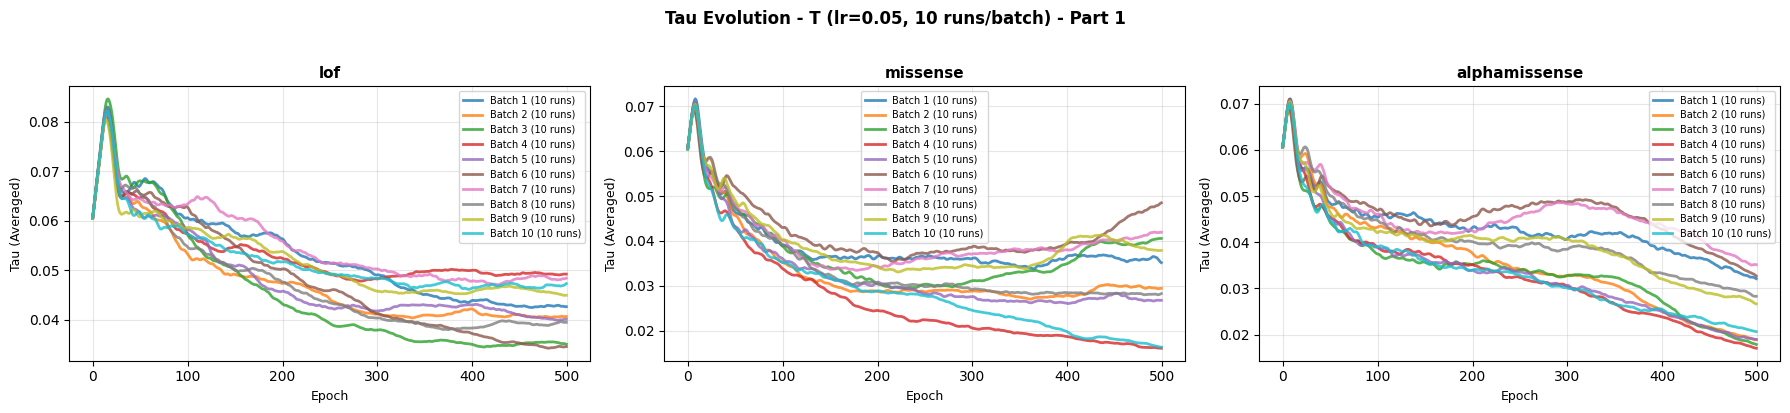

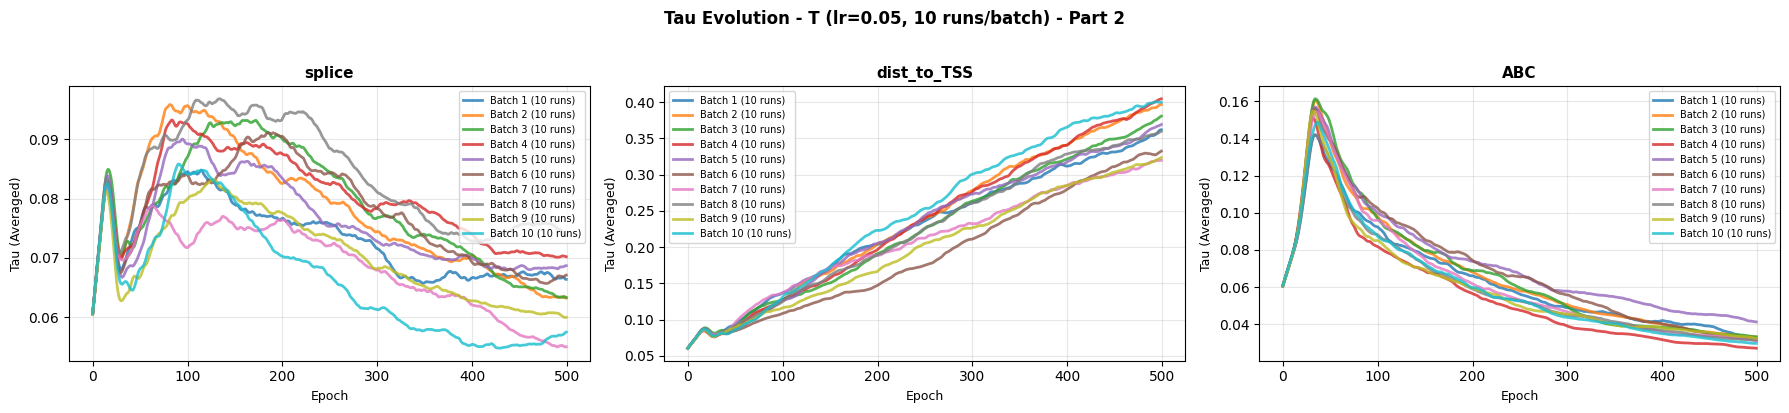

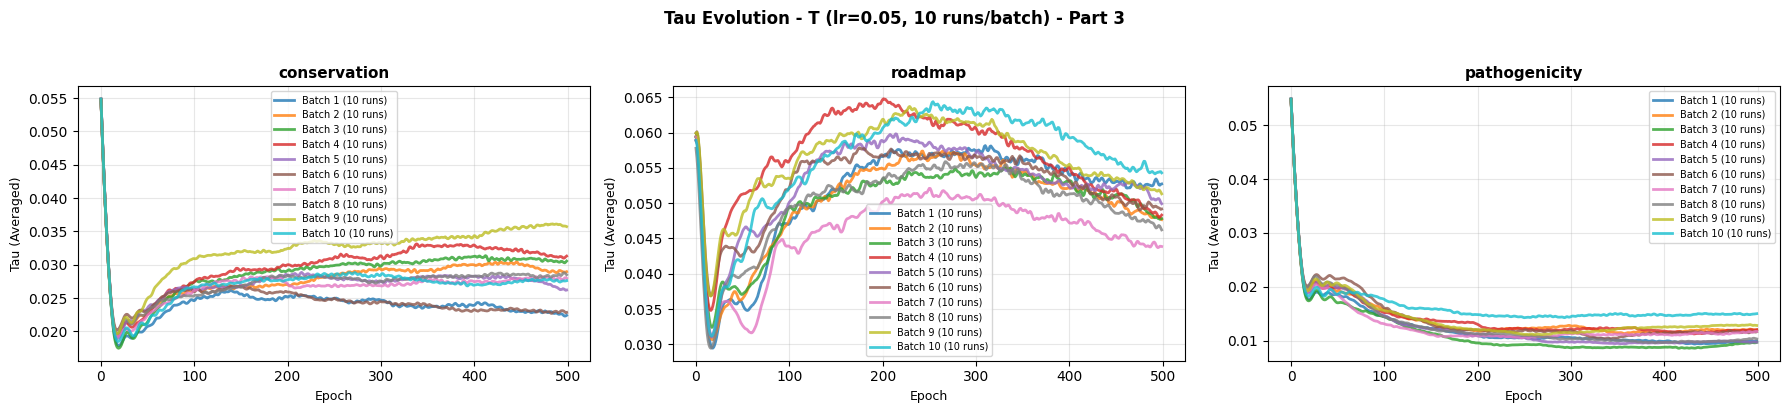

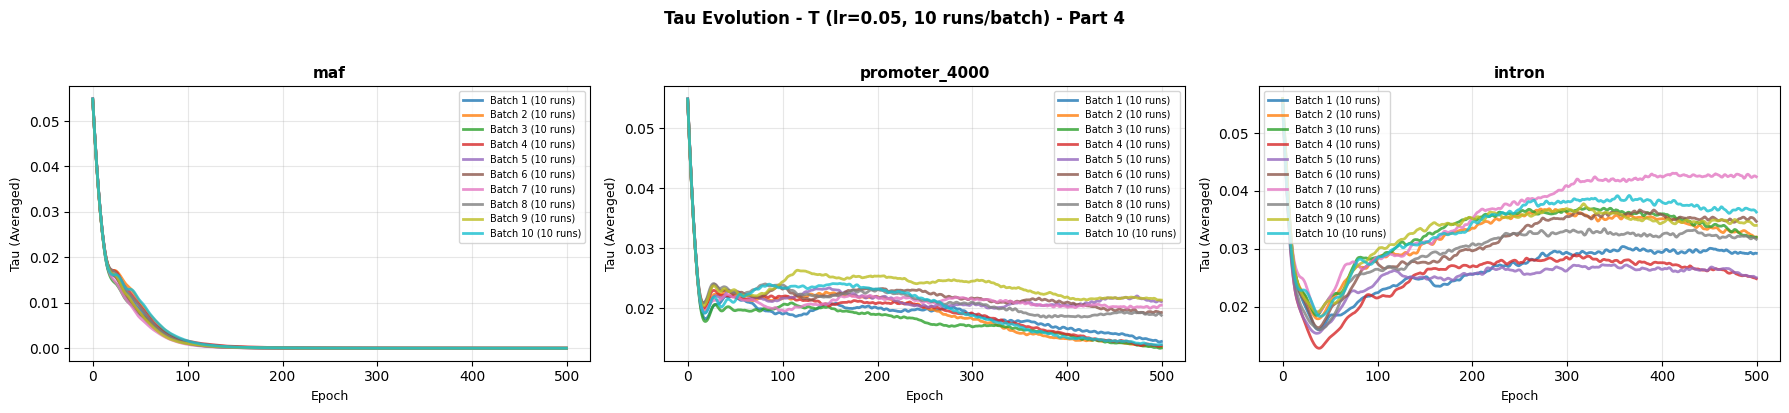

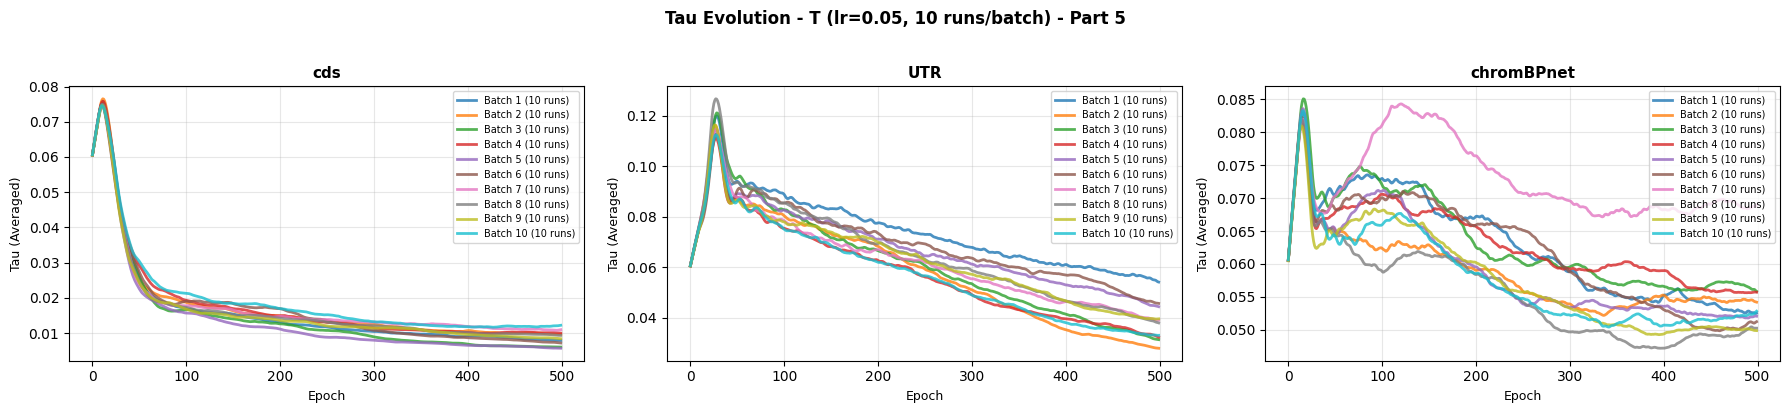

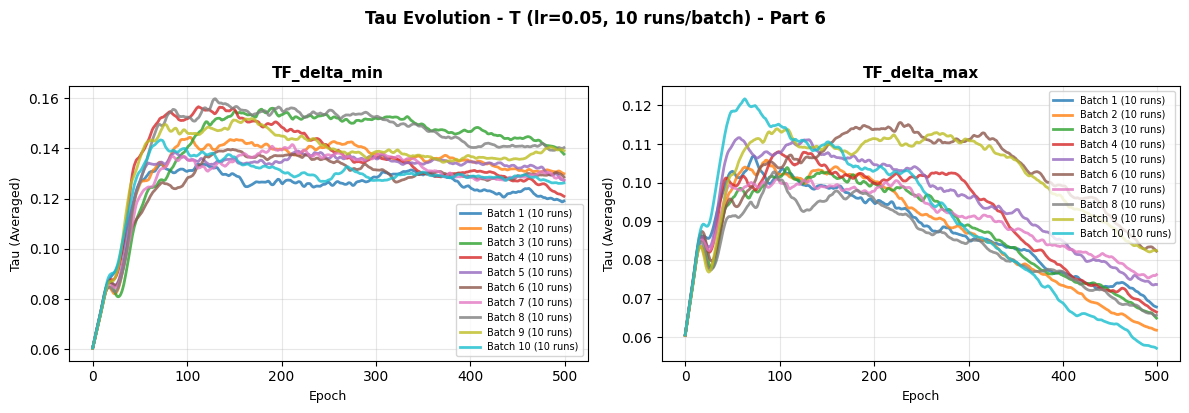


Processing NoT runs (batching by 50)


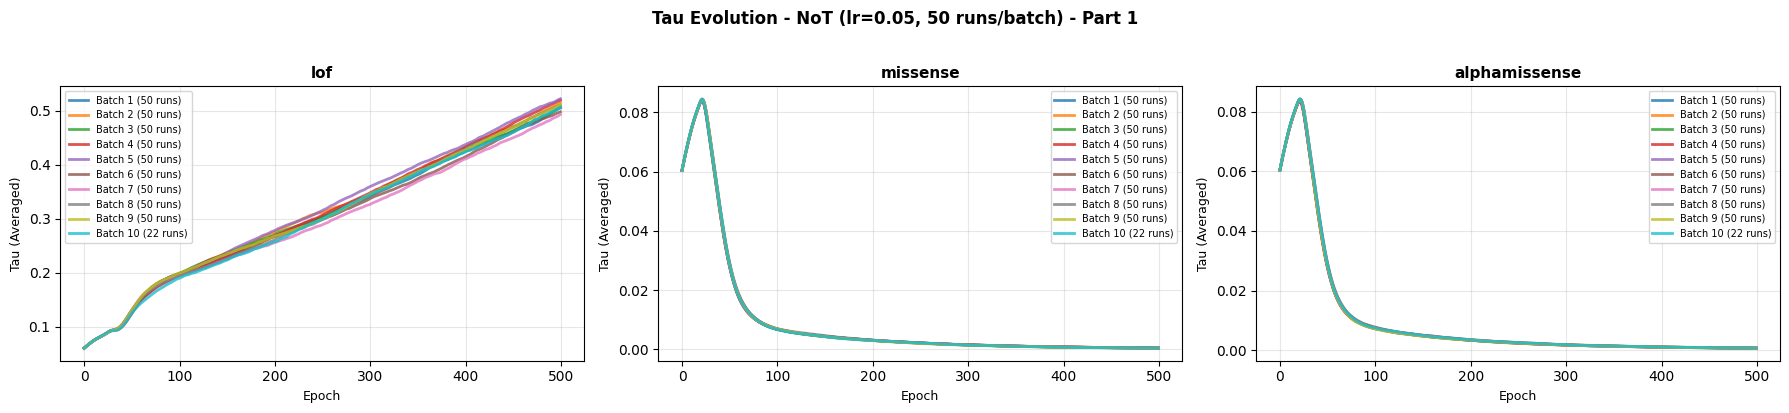

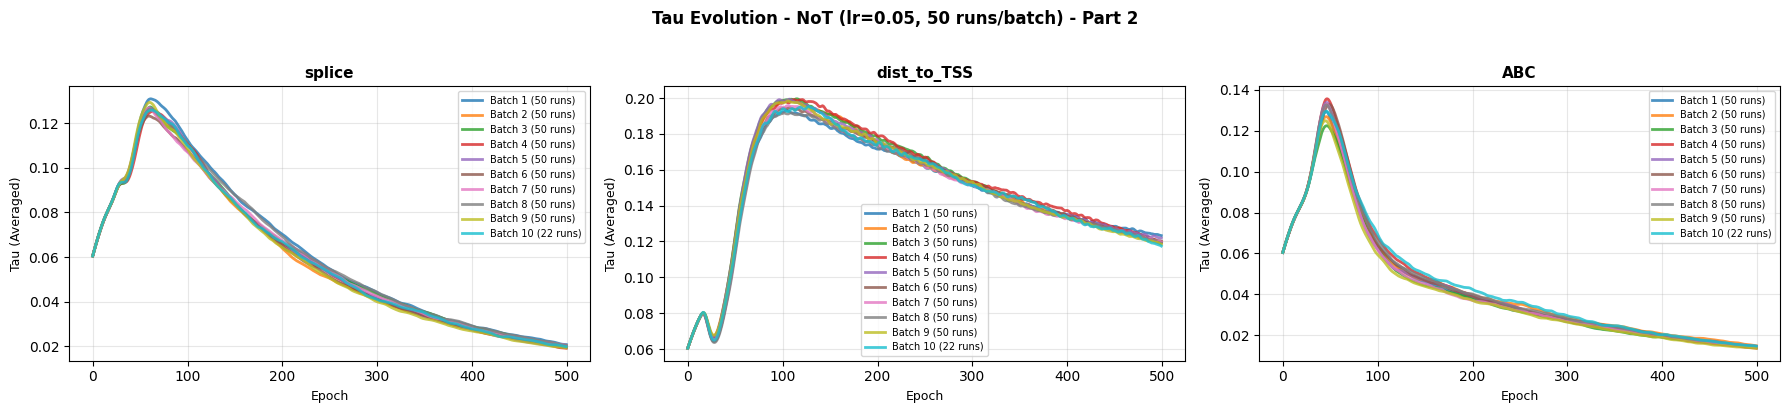

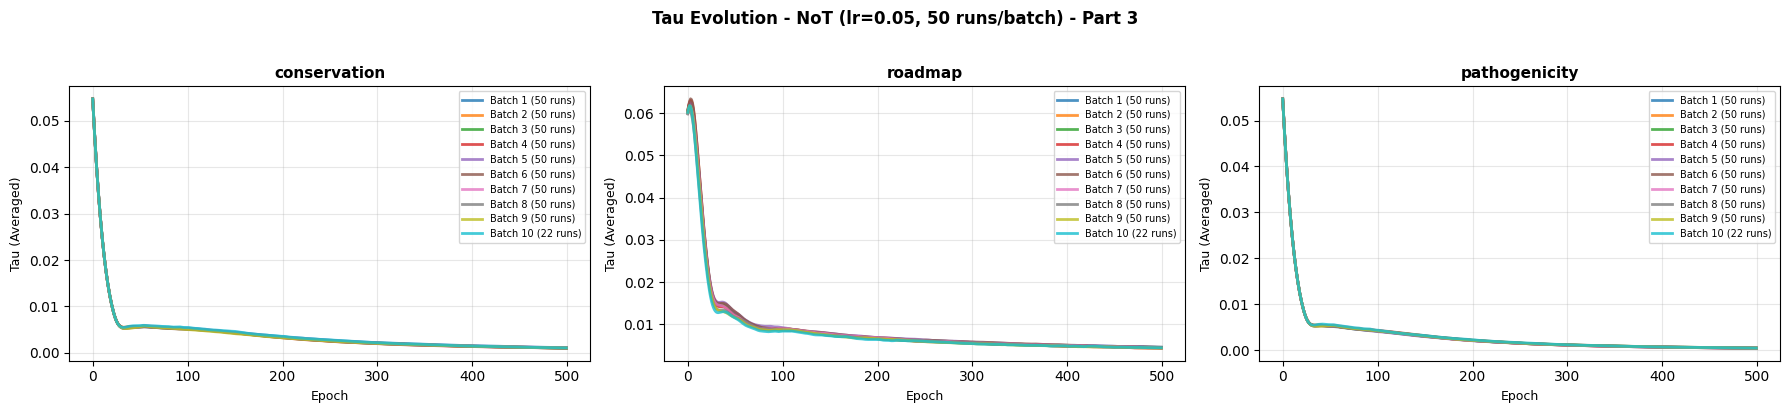

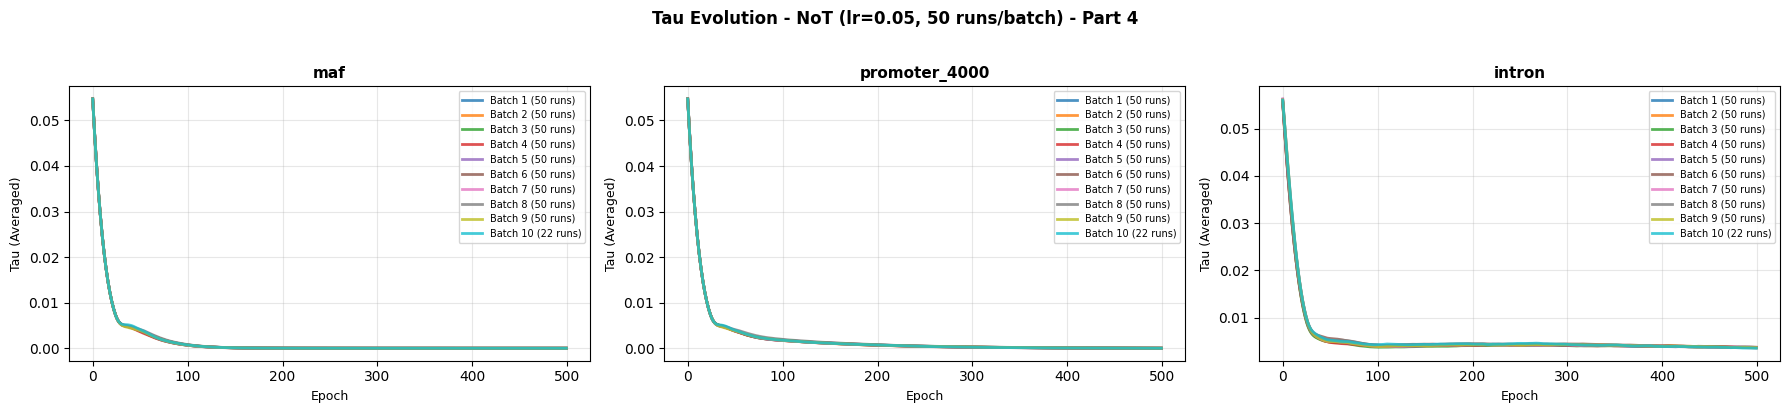

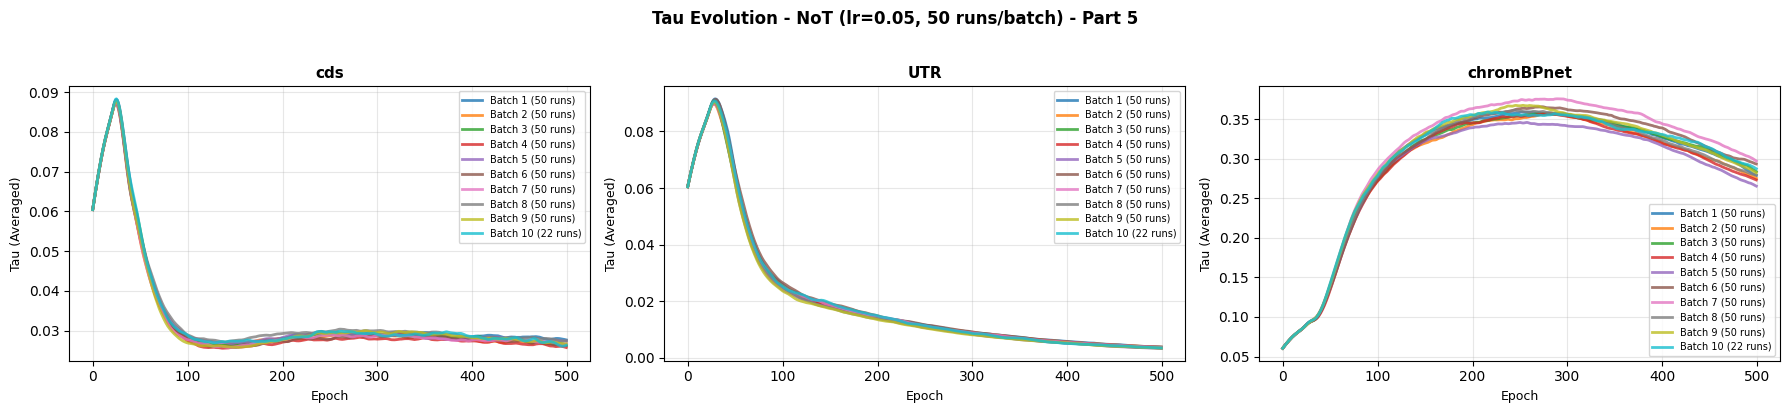

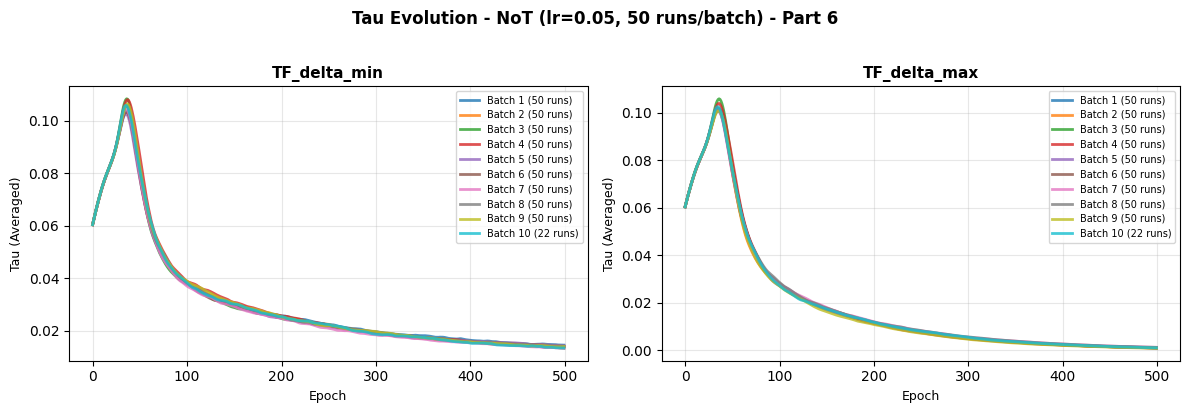

In [20]:
# Load tau history from all runs and average across batches (T: 10 runs, NoT: 50 runs)
batch_sizes = {'T': 10, 'NoT': 50}
lr_dicts = {'T': lr_to_runs_T, 'NoT': lr_to_runs_NoT}

for run_type in ['T', 'NoT']:
    lr_dict = lr_dicts[run_type]
    if len(lr_dict) == 0:
        continue
    
    N = batch_sizes[run_type]
    print(f"\n{'='*80}")
    print(f"Processing {run_type} runs (batching by {N})")
    print(f"{'='*80}")
    
    for lr, run_ids in lr_dict.items():
        tau_history_data = {}
        missing_count = 0
        for run_id in run_ids:
            tau_hist = load_run_files(run_id, what=["tau_history"]).get("tau_history")
            if tau_hist is not None:
                # Load config to get metadata
                config_file = find_config_file(run_id)
                if config_file:
                    try:
                        with open(config_file, 'r') as f:
                            config = yaml.safe_load(f)
                        tau_hist['run_id'] = run_id
                        tau_hist['epoch'] = tau_hist.index
                        tau_hist['lr'] = config.get('lr', 'unknown')
                        tau_hist['epochs'] = config.get('epochs', 'unknown')
                        tau_history_data[run_id] = tau_hist
                    except Exception:
                        missing_count += 1
                else:
                    missing_count += 1
            else:
                missing_count += 1
        
        if missing_count > 0:
            print(f"Note: {missing_count} runs did not have tau_history files (out of {len(run_ids)} total runs)")

        if len(tau_history_data) == 0:
            print(f"No tau history data found for {run_type} runs with lr={lr}!")
            continue
        else:
            # Group runs into batches
            sorted_run_ids = sorted(tau_history_data.keys())
            run_to_batch = {run_id: i // N for i, run_id in enumerate(sorted_run_ids)}
            
            # Get all annotation names (assuming all runs have same annotations)
            first_run = list(tau_history_data.keys())[0]
            annotations = [col for col in tau_history_data[first_run].columns 
                        if col not in ['run_id', 'epoch', 'lr', 'epochs']]
            
            # Average tau history across runs in each batch
            batch_tau_history = {}
            for batch_num in sorted(set(run_to_batch.values())):
                runs_in_batch = [run_id for run_id, b in run_to_batch.items() if b == batch_num]
                if len(runs_in_batch) == 0:
                    continue
                
                # Get epochs (assuming all runs have same epochs)
                first_run_in_batch = runs_in_batch[0]
                epochs = tau_history_data[first_run_in_batch].index.values
                
                # Collect tau values for each epoch and annotation across runs in batch
                batch_avg = pd.DataFrame(index=epochs)
                batch_avg.index.name = 'epoch'
                
                for annotation in annotations:
                    annotation_values = []
                    for epoch in epochs:
                        epoch_values = []
                        for run_id in runs_in_batch:
                            tau_hist = tau_history_data[run_id]
                            if epoch in tau_hist.index:
                                epoch_values.append(tau_hist.loc[epoch, annotation])
                        if len(epoch_values) > 0:
                            annotation_values.append(np.mean(epoch_values))
                        else:
                            annotation_values.append(np.nan)
                    batch_avg[annotation] = annotation_values
                
                batch_avg = batch_avg.reset_index()
                batch_tau_history[batch_num] = batch_avg
            
            # Create batch labels
            batch_labels = {}
            for batch_num in sorted(batch_tau_history.keys()):
                runs_in_batch = [run_id for run_id, b in run_to_batch.items() if b == batch_num]
                batch_labels[batch_num] = f"Batch {batch_num+1} ({len(runs_in_batch)} runs)"
            
            # Faceted plot: 3 subplots per plot for easy copying to slides
            n_annotations = len(annotations)
            annotations_per_plot = 3
            
            # Create multiple plots, each with 3 subplots
            for plot_idx in range(0, n_annotations, annotations_per_plot):
                plot_annotations = annotations[plot_idx:plot_idx + annotations_per_plot]
                n_plots = len(plot_annotations)
                
                fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 4))
                if n_plots == 1:
                    axes = [axes]
                
                for subplot_idx, annotation in enumerate(plot_annotations):
                    ax = axes[subplot_idx]
                    for batch_num in sorted(batch_tau_history.keys()):
                        batch_data = batch_tau_history[batch_num]
                        ax.plot(batch_data['epoch'], batch_data[annotation], 
                            label=batch_labels[batch_num], alpha=0.8, linewidth=2)
                    ax.set_title(f'{annotation}', fontsize=11, fontweight='bold')
                    ax.set_xlabel('Epoch', fontsize=9)
                    ax.set_ylabel('Tau (Averaged)', fontsize=9)
                    ax.legend(loc='best', fontsize=7)
                    ax.grid(alpha=0.3)
                
                plt.suptitle(f'Tau Evolution - {run_type} (lr={lr}, {N} runs/batch) - Part {plot_idx//annotations_per_plot + 1}', 
                            fontsize=12, fontweight='bold', y=1.02)
                plt.tight_layout()
                plt.show()
      
        

   
    


Processing T runs (batching by 10)
Batch 1 (T, lr=0.05, 10 runs): Average proportion of variants kept: 49.80% ± 28.37%
Batch 2 (T, lr=0.05, 10 runs): Average proportion of variants kept: 54.35% ± 20.22%
Batch 3 (T, lr=0.05, 10 runs): Average proportion of variants kept: 48.59% ± 16.28%
Batch 4 (T, lr=0.05, 10 runs): Average proportion of variants kept: 60.08% ± 15.82%
Batch 5 (T, lr=0.05, 10 runs): Average proportion of variants kept: 50.39% ± 23.67%
Batch 6 (T, lr=0.05, 10 runs): Average proportion of variants kept: 43.33% ± 19.51%
Batch 7 (T, lr=0.05, 10 runs): Average proportion of variants kept: 42.64% ± 25.24%
Batch 8 (T, lr=0.05, 10 runs): Average proportion of variants kept: 50.74% ± 20.75%
Batch 9 (T, lr=0.05, 10 runs): Average proportion of variants kept: 47.45% ± 16.69%
Batch 10 (T, lr=0.05, 10 runs): Average proportion of variants kept: 56.89% ± 21.08%


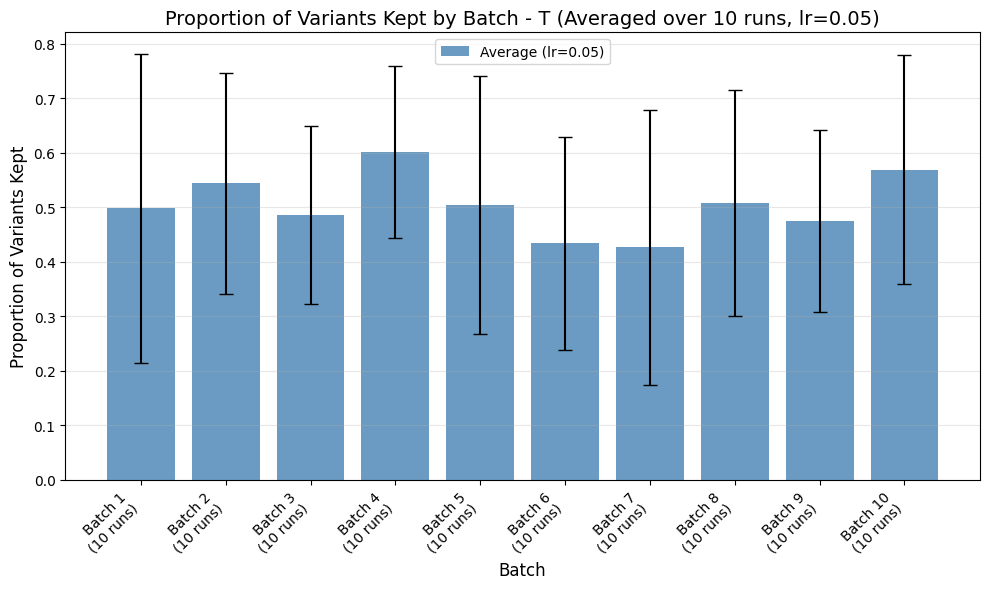

In [21]:

def load_Z(genes, annotations_dir):
    Z_list = []   
    for gene in genes:
        path = os.path.join(annotations_dir, f"{gene}_annotations.tsv.gz")
        Z = pd.read_csv(path, sep = "\t")
        Z_list.append(Z)
    Zs = pd.concat(Z_list)
    Z = Zs.drop(['promoter_3000', 'promoter_2000'], axis=1, errors='ignore')
    log_cols = Z.filter(like="log_counts").columns
    Z["chromBPnet"] = Z[log_cols].max(axis=1)
    Z = Z.drop(columns=log_cols)
    
    enformer = Z.filter(like="TF_delta_min").columns
    Z["TF_delta_min"] = Z[enformer].max(axis=1)
    Z = Z.drop(columns=enformer)
    
    enformer = Z.filter(like="TF_delta_max").columns
    Z["TF_delta_max"] = Z[enformer].max(axis=1)
    Z = Z.drop(columns=enformer)
    return Z

# Process only T runs for proportion of variants kept (NoT runs not needed)
batch_sizes = {'T': 10}
lr_dicts = {'T': lr_to_runs_T}

for run_type in ['T']:  # Only process T runs
    lr_dict = lr_dicts[run_type]
    if len(lr_dict) == 0:
        continue
    
    N = batch_sizes[run_type]
    print(f"\n{'='*80}")
    print(f"Processing {run_type} runs (batching by {N})")
    print(f"{'='*80}")
    
    for lr, run_ids in lr_dict.items():
        # Group runs into batches
        sorted_run_ids = sorted(run_ids)
        run_to_batch = {run_id: i // N for i, run_id in enumerate(sorted_run_ids)}
        
        # Collect proportions for each batch
        batch_proportions = defaultdict(list)
        batch_run_ids = defaultdict(list)
        
        for run_id in run_ids:
            try:
                config_file = find_config_file(run_id)
                if not config_file:
                    print(f"Warning: Could not find config for {run_id}")
                    continue
                    
                with open(config_file, 'r') as f:
                    config = yaml.safe_load(f)

                genes  = config['genes']
                annotations_dir = config['annotation_dir']
                tau_T = load_run_files(run_id, what=["tau_T"]).get("tau_T")
                
                if tau_T is None:
                    print(f"Warning: Could not load tau_T for {run_id}")
                    continue
                    
                Z = load_Z(genes, annotations_dir)
                Z['parmigiano'] = Z[list(tau_T['Annotation'])] @ list(tau_T['Tau'])
                Z['Kept'] = np.where(Z['parmigiano']>=tau_T['Filter Threshold'].iloc[0], 1, 0)
                proportion = Z['Kept'].sum() / len(Z)
                
                batch_num = run_to_batch[run_id]
                batch_proportions[batch_num].append(proportion)
                batch_run_ids[batch_num].append(run_id)
            except Exception as e:
                print(f"Warning: Error processing {run_id}: {e}")
        
        # Calculate average proportions per batch
        batch_avg_proportions = {}
        for batch_num in sorted(batch_proportions.keys()):
            avg_prop = np.mean(batch_proportions[batch_num])
            std_prop = np.std(batch_proportions[batch_num])
            n_runs = len(batch_proportions[batch_num])
            batch_avg_proportions[batch_num] = {
                'mean': avg_prop,
                'std': std_prop,
                'n_runs': n_runs
            }
            print(f"Batch {batch_num+1} ({run_type}, lr={lr}, {n_runs} runs): "
                  f"Average proportion of variants kept: {avg_prop:.2%} ± {std_prop:.2%}")
        
        # Create visualization
        if len(batch_avg_proportions) > 0:
            batch_nums = sorted(batch_avg_proportions.keys())
            batch_labels = [f"Batch {b+1}\n({batch_avg_proportions[b]['n_runs']} runs)" 
                           for b in batch_nums]
            means = [batch_avg_proportions[b]['mean'] for b in batch_nums]
            stds = [batch_avg_proportions[b]['std'] for b in batch_nums]
            
            fig, ax = plt.subplots(figsize=(10, 6))
            x = np.arange(len(batch_nums))
            ax.bar(x, means, yerr=stds, alpha=0.8, capsize=5, 
                   label=f'Average (lr={lr})', color='steelblue')
            ax.set_xlabel('Batch', fontsize=12)
            ax.set_ylabel('Proportion of Variants Kept', fontsize=12)
            ax.set_title(f'Proportion of Variants Kept by Batch - {run_type} (Averaged over {N} runs, lr={lr})', 
                         fontsize=14)
            ax.set_xticks(x)
            ax.set_xticklabels(batch_labels, rotation=45, ha='right')
            ax.grid(alpha=0.3, axis='y')
            ax.legend()
            plt.tight_layout()
            plt.show()
 


Processing T runs (batching by 10)


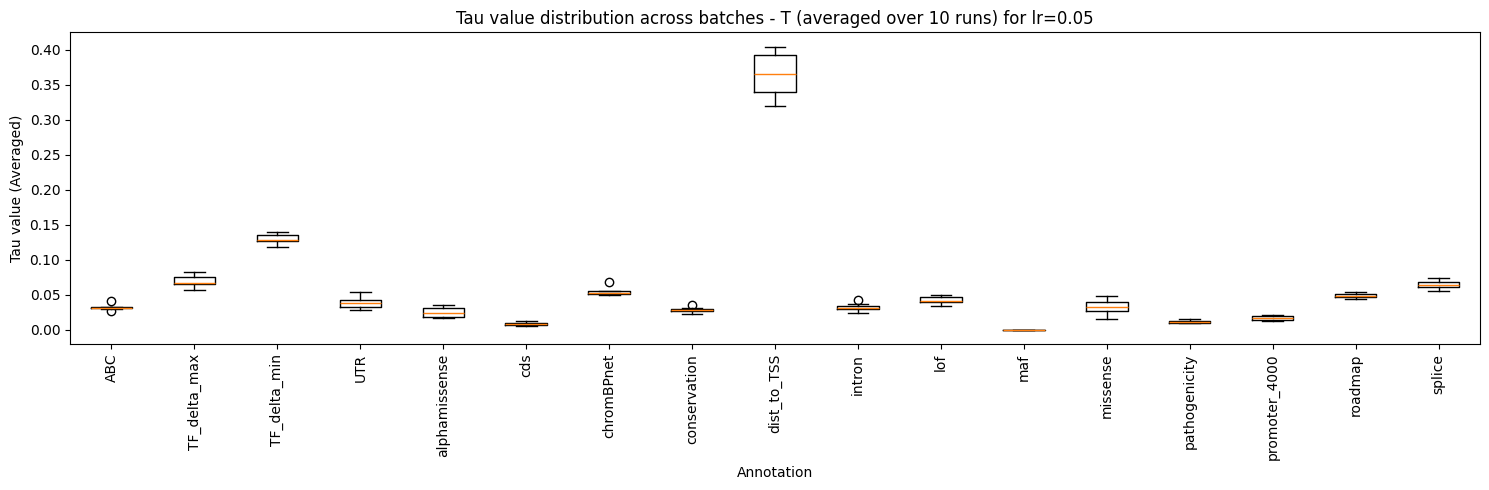

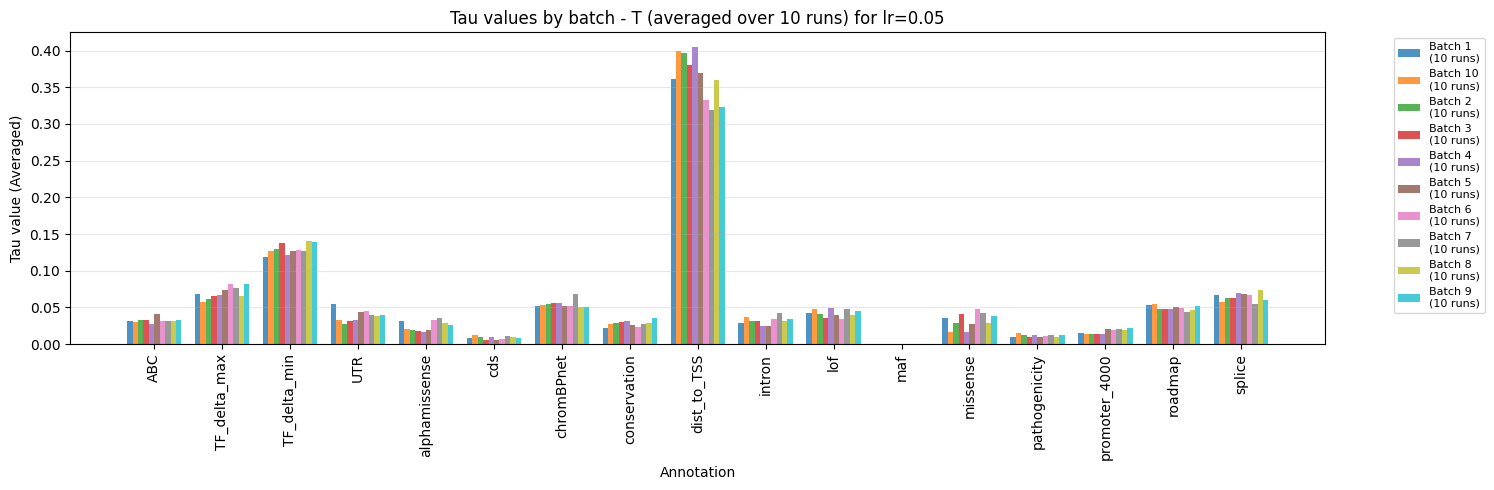


Processing NoT runs (batching by 50)


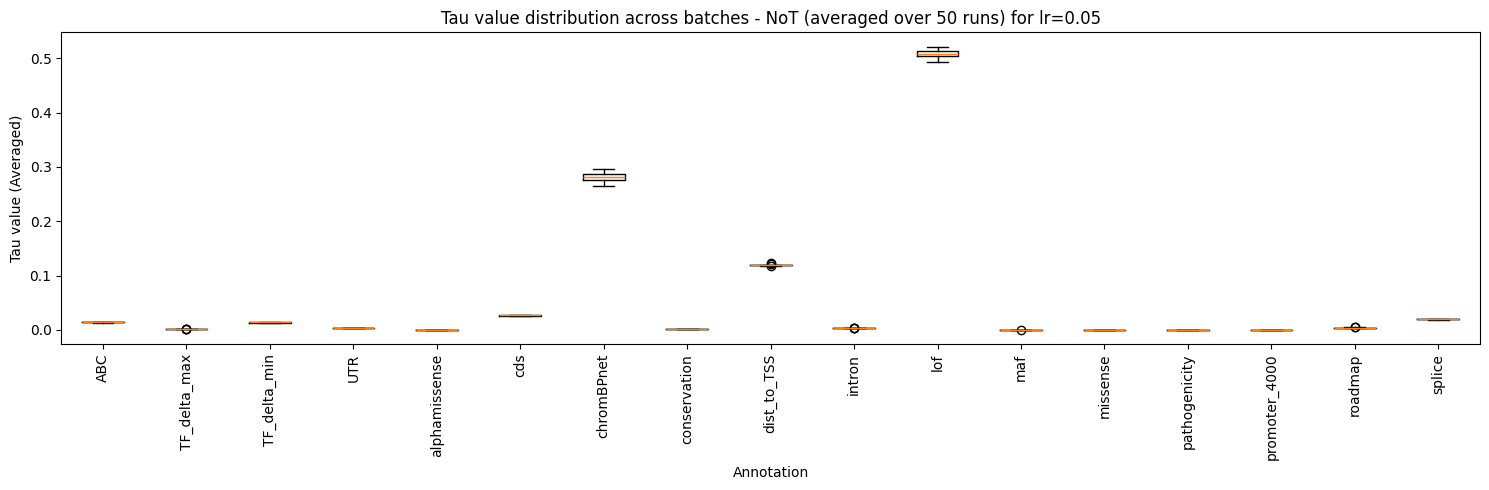

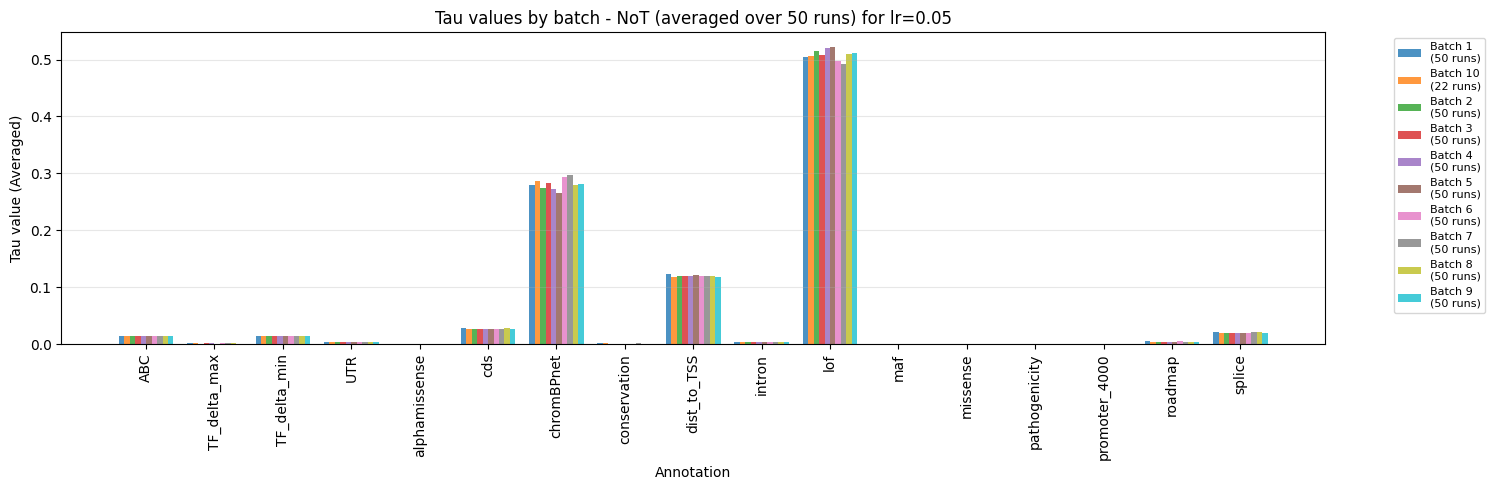

In [22]:
# Final tau value distribution, averaged across batches (T: 10 runs, NoT: 50 runs)
batch_sizes = {'T': 10, 'NoT': 50}
lr_dicts = {'T': lr_to_runs_T, 'NoT': lr_to_runs_NoT}

for run_type in ['T', 'NoT']:
    lr_dict = lr_dicts[run_type]
    if len(lr_dict) == 0:
        continue
    
    N = batch_sizes[run_type]
    print(f"\n{'='*80}")
    print(f"Processing {run_type} runs (batching by {N})")
    print(f"{'='*80}")
    
    for lr, run_ids in lr_dict.items():
        # Group runs into batches
        sorted_run_ids = sorted(run_ids)
        run_to_batch = {run_id: i // N for i, run_id in enumerate(sorted_run_ids)}
        
        # Collect tau values by batch and annotation
        batch_annotation_taus = defaultdict(lambda: defaultdict(list))
        
        for run_id in run_ids:
            try:
                tau_T = load_run_files(run_id, what=["tau_T"]).get("tau_T")
                if tau_T is None:
                    continue
                batch_num = run_to_batch[run_id]
                for annotation in tau_T['Annotation']:
                    tau_value = tau_T[tau_T['Annotation'] == annotation]['Tau'].values[0]
                    batch_annotation_taus[batch_num][annotation].append(tau_value)
            except Exception as e:
                print(f"Warning: Could not load tau_T for {run_id}: {e}")
        
        # Average tau values across runs in each batch
        batch_avg_taus = {}
        for batch_num in sorted(batch_annotation_taus.keys()):
            batch_avg_taus[batch_num] = {}
            for annotation, tau_values in batch_annotation_taus[batch_num].items():
                batch_avg_taus[batch_num][annotation] = np.mean(tau_values)
        
        # Create batch labels
        batch_labels = {}
        for batch_num in sorted(batch_avg_taus.keys()):
            runs_in_batch = [run_id for run_id, b in run_to_batch.items() if b == batch_num]
            batch_labels[batch_num] = f"Batch {batch_num+1}\n({len(runs_in_batch)} runs)"
        
        # Convert to DataFrame for plotting
        annotation_list = sorted(set(ann for batch in batch_avg_taus.values() for ann in batch.keys()))
        tau_data = []
        for batch_num in sorted(batch_avg_taus.keys()):
            for annotation in annotation_list:
                if annotation in batch_avg_taus[batch_num]:
                    tau_data.append({
                        'batch': batch_labels[batch_num],
                        'annotation': annotation,
                        'tau': batch_avg_taus[batch_num][annotation]
                    })
        
        tau_df = pd.DataFrame(tau_data)
        
        # Plot tau value distribution as boxplot
        if len(tau_df) > 0:
            fig, ax = plt.subplots(figsize=(15, 5))
            
            annotations_unique = tau_df['annotation'].unique()
            positions = []
            data_for_boxplot = []
            labels = []
            
            for i, annotation in enumerate(sorted(annotations_unique)):
                annotation_data = tau_df[tau_df['annotation'] == annotation]['tau'].values
                if len(annotation_data) > 0:
                    positions.append(i + 1)
                    data_for_boxplot.append(annotation_data)
                    labels.append(annotation)
            
            bp = ax.boxplot(data_for_boxplot, positions=positions, tick_labels=labels)
            ax.set_title(f"Tau value distribution across batches - {run_type} (averaged over {N} runs) for lr={lr}")
            ax.set_xlabel("Annotation")
            ax.set_ylabel("Tau value (Averaged)")
            ax.tick_params(axis='x', rotation=90)
            plt.tight_layout()
            plt.show()
            
            # Also create a grouped bar plot showing each batch separately
            n_batches = len(tau_df['batch'].unique())
            if n_batches > 1:
                fig, ax = plt.subplots(figsize=(15, 5))
                x = np.arange(len(annotations_unique))
                width = 0.8 / n_batches
                
                for batch_idx, batch_label in enumerate(sorted(tau_df['batch'].unique())):
                    batch_data = tau_df[tau_df['batch'] == batch_label]
                    batch_tau_values = [batch_data[batch_data['annotation'] == ann]['tau'].values[0] 
                                       if len(batch_data[batch_data['annotation'] == ann]) > 0 else 0
                                       for ann in sorted(annotations_unique)]
                    offset = (batch_idx - n_batches/2 + 0.5) * width
                    ax.bar(x + offset, batch_tau_values, width, label=batch_label, alpha=0.8)
                
                ax.set_xlabel("Annotation")
                ax.set_ylabel("Tau value (Averaged)")
                ax.set_title(f"Tau values by batch - {run_type} (averaged over {N} runs) for lr={lr}")
                ax.set_xticks(x)
                ax.set_xticklabels(sorted(annotations_unique), rotation=90)
                ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
                ax.grid(alpha=0.3, axis='y')
                plt.tight_layout()
                plt.show()


    


In [23]:
# distribution of tau values across runs, for different learning rates
